# Nonlinear Dimensionality Reduction and Visualization

Many machine learning algorithms assume that input data is linearly separable. However, real-world applications frequently involve nonlinear problems where linear transformation techniques like PCA and LDA are not the best choices.

The development of nonlinear dimensionality reduction is often referred to as **manifold learning**. A manifold is a lower-dimensional topological space embedded within a high-dimensional space. Manifold learning algorithms capture the complicated structure of data to project it onto a lower-dimensional space while preserving the relationships between data points.

While powerful, these algorithms are notoriously difficult to use. Poor hyperparameter choices can cause more harm than good, and it is often hard to assess the quality of the results since projecting into two or three dimensions may not sufficiently capture complex relationships.

## t-Distributed Stochastic Neighbor Embedding (t-SNE)

**t-SNE** is a nonlinear dimensionality reduction technique frequently used to visualize complex, high-dimensional datasets in two or three dimensions.

* **How it works:** t-SNE models data points based on their pair-wise distances in the original high-dimensional feature space. It then learns to embed these points into a lower-dimensional space by finding a probability distribution of pair-wise distances that closely matches the distribution in the original space.
* **Limitation:** Because t-SNE projects points directly and does not create a projection matrix, it is intended strictly for visualization purposes and cannot be applied to project *new* data points.

---

### Step-by-Step Implementation in scikit-learn

We can demonstrate t-SNE using the Digits dataset, which consists of 1,797 low-resolution ($8 \times 8$ pixel) images of handwritten digits from 0 to 9.

#### 1. Loading and Visualizing the Data

First, we load the dataset and plot a few examples to understand what we are working with.

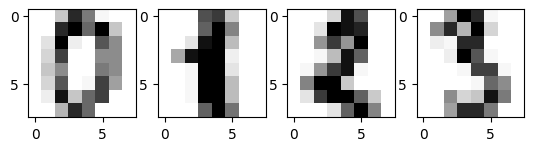

In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

digits = load_digits()

fig, ax = plt.subplots(1, 4)
for i in range(4):
    ax[i].imshow(digits.images[i], cmap='Greys')
plt.show()

#### 2. Preparing the Data

The dataset contains 64 features per image (the pixels). We assign these features and their corresponding target labels to variables.

In [2]:
# Check the shape: Should output (1797, 64)
print(digits.data.shape)

y_digits = digits.target
X_digits = digits.data

(1797, 64)


#### 3. Fitting the t-SNE Model

We initialize the `TSNE` class to project the 64-dimensional data onto a 2-dimensional space. Specifying `init='pca'` is recommended as it helps preserve the global data structure.

In [3]:
from sklearn.manifold import TSNE

# Initialize and fit the t-SNE model
tsne = TSNE(n_components=2, init='pca', random_state=123)
X_digits_tsne = tsne.fit_transform(X_digits)

*(Note: t-SNE also has hyperparameters like `perplexity` and learning rate (`epsilon`), but scikit-learn's defaults are used here.)*

#### 4. Plotting the 2D t-SNE Embeddings

Because t-SNE is unsupervised, we only use the class labels (`y_digits`) for the color argument to visually assess how well it separated the digits.

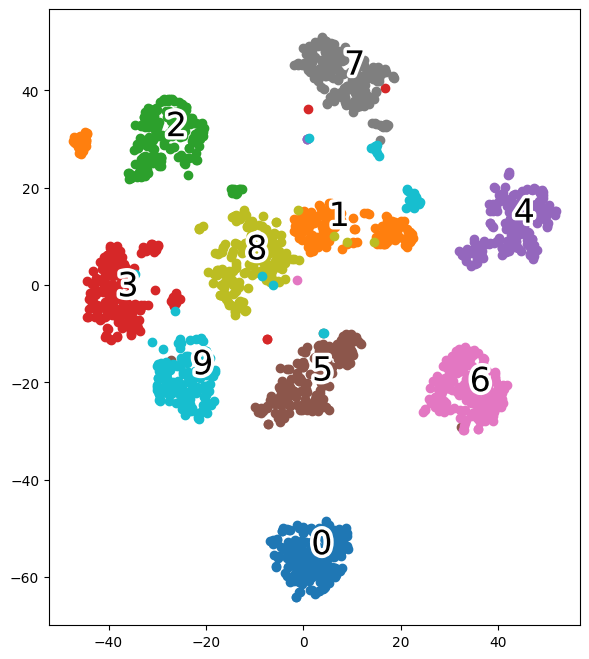

In [4]:
import matplotlib.patheffects as PathEffects
import numpy as np

def plot_projection(x, colors):
    f = plt.figure(figsize=(8, 8))
    ax = plt.subplot(aspect='equal')

    # Plot the individual data points
    for i in range(10):
        plt.scatter(x[colors == i, 0], x[colors == i, 1])

    # Overlay the class labels in the median center of the clusters
    for i in range(10):
        xtext, ytext = np.median(x[colors == i, :], axis=0)
        txt = ax.text(xtext, ytext, str(i), fontsize=24)
        txt.set_path_effects([
            PathEffects.Stroke(linewidth=5, foreground="w"),
            PathEffects.Normal()
        ])

plot_projection(X_digits_tsne, y_digits)
plt.show()

The output generally separates the classes well, though minor class mixing can occur due to illegible handwriting (e.g., a handwritten '3' might closely resemble a '9').

---

## Uniform Manifold Approximation and Projection (UMAP)

An alternative to t-SNE is **UMAP**. While it produces similarly good visual results, it is generally faster. More importantly, unlike t-SNE, UMAP *can* be used to project new data. This capability makes UMAP a highly attractive dimensionality reduction technique to use directly within machine learning pipelines, similar to how PCA is used.